# MDN cross-validation: gas density only (~4k params)

Features: gas_surfdens, kappa (epicyclic frequency)

Architecture: 2 layers, 64 hidden, 3 components.
Leave-one-galaxy-out, reports R² and NLL per fold.

In [3]:
import sys
from pathlib import Path

project_root = str(Path.cwd().parents[1]) if Path.cwd().name == "mdn" else str(Path.cwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

from sfemulator.mdn.model import train_mdn, predict_mean, predict_nll, sample
from sfemulator.data.loader import (
    load_all_galaxies, prepare_log_data, GALAXIES,
    SURFDENS_TO_MSUN_PC2, SFR_SURFDENS_TO_MSUN_YR_KPC2,
)

FEATURE_INDICES = [0, 3]

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

Device: mps


In [4]:
SNAP_DIR = Path("../../snapshots")
data = load_all_galaxies(SNAP_DIR)
galaxy_names = list(GALAXIES.keys())
print(galaxy_names)

MW: 4 snapshots, 20360 star-forming pixels
NGC300: 31 snapshots, 40556 star-forming pixels
ETG-vlM: 31 snapshots, 12532 star-forming pixels
ETG-lowM: 31 snapshots, 28816 star-forming pixels
ETG-medM: 30 snapshots, 19053 star-forming pixels
ETG-hiM: 22 snapshots, 31052 star-forming pixels
['MW', 'NGC300', 'ETG-vlM', 'ETG-lowM', 'ETG-medM', 'ETG-hiM']


In [5]:
# Leave-one-galaxy-out: train on N-1, evaluate on held-out 1
results = {}

for held_out in galaxy_names:
    train_names = [n for n in galaxy_names if n != held_out]
    print(f"\n=== Fold: held out {held_out}, training on {train_names} ===")

    # Prepare training data
    X_train_log, y_train_log, _ = prepare_log_data(data, train_names, feature_indices=FEATURE_INDICES)
    scaler = StandardScaler().fit(X_train_log)
    X_scaled = scaler.transform(X_train_log).astype(np.float32)
    y_train = y_train_log.astype(np.float32)
    print(f"  Training samples: {len(y_train)}")

    # Train (~4k params: 2 layers, 64 hidden, 8 components)
    model, losses = train_mdn(
        X_scaled, y_train,
        n_hidden=64, n_layers=2, n_components=8,
        lr=1e-3, n_epochs=50, batch_size=2048, device=device,
    )

    # Evaluate on held-out galaxy
    ctx_test, sfr_sd_test = data[held_out]
    log_ctx_test = np.log10(ctx_test[:, FEATURE_INDICES])
    log_sfr_test = np.log10(sfr_sd_test)
    finite_test = np.all(np.isfinite(log_ctx_test), axis=1) & np.isfinite(log_sfr_test)

    X_test_scaled = scaler.transform(log_ctx_test[finite_test]).astype(np.float32)
    X_test_t = torch.tensor(X_test_scaled).to(device)
    y_test_true = log_sfr_test[finite_test]
    y_test_t = torch.tensor(y_test_true.astype(np.float32)).to(device)

    y_pred = predict_mean(model, X_test_t)
    r2 = r2_score(y_test_true, y_pred)
    nll = predict_nll(model, X_test_t, y_test_t)

    # KS98 baseline on held-out galaxy
    log_gas_msun = np.log10(ctx_test[finite_test, 0] * SURFDENS_TO_MSUN_PC2)
    y_pred_ks = np.log10(2.5e-4) + 1.4 * log_gas_msun - np.log10(SFR_SURFDENS_TO_MSUN_YR_KPC2)
    r2_ks = r2_score(y_test_true, y_pred_ks)
    # KS98 NLL with variance from training set
    ks_train_pred = np.log10(2.5e-4) + 1.4 * np.log10(
        np.concatenate([data[n][0] for n in train_names])[prepare_log_data(data, train_names, feature_indices=FEATURE_INDICES)[2], 0] * SURFDENS_TO_MSUN_PC2
    ) - np.log10(SFR_SURFDENS_TO_MSUN_YR_KPC2)
    ks_var = np.var(y_train_log - ks_train_pred)
    nll_ks = 0.5 * np.log(2 * np.pi * ks_var) + 0.5 * np.mean((y_test_true - y_pred_ks)**2) / ks_var

    results[held_out] = {
        "model": model, "scaler": scaler, "losses": losses,
        "r2": r2, "nll": nll, "r2_ks": r2_ks, "nll_ks": nll_ks,
        "finite_test": finite_test,
    }
    print(f"  {held_out}: R²={r2:.4f} (KS98={r2_ks:.4f}), NLL={nll:.4f} (KS98={nll_ks:.4f})")


=== Fold: held out MW, training on ['NGC300', 'ETG-vlM', 'ETG-lowM', 'ETG-medM', 'ETG-hiM'] ===
  Training samples: 129025


/Users/smrj3/GalactISM/sfemulator/data/loader.py:91: RuntimeWarning: invalid value encountered in log10
  log_ctx = np.log10(all_ctx)


  Epoch   50/50  NLL = 1.2178
  MW: R²=0.0783 (KS98=-0.1423), NLL=1.7039 (KS98=3.4683)

=== Fold: held out NGC300, training on ['MW', 'ETG-vlM', 'ETG-lowM', 'ETG-medM', 'ETG-hiM'] ===
  Training samples: 109829


/var/folders/30/hdkspf4j307b3qg9j5yb_cgm0000gp/T/ipykernel_71407/42866920.py:24: RuntimeWarning: invalid value encountered in log10
  log_ctx_test = np.log10(ctx_test[:, FEATURE_INDICES])
/Users/smrj3/GalactISM/sfemulator/data/loader.py:91: RuntimeWarning: invalid value encountered in log10
  log_ctx = np.log10(all_ctx)


  Epoch   50/50  NLL = 1.2283
  NGC300: R²=0.0470 (KS98=-0.1685), NLL=1.7318 (KS98=3.7930)

=== Fold: held out ETG-vlM, training on ['MW', 'NGC300', 'ETG-lowM', 'ETG-medM', 'ETG-hiM'] ===
  Training samples: 136294


...

/Users/smrj3/GalactISM/sfemulator/data/loader.py:91: RuntimeWarning: invalid value encountered in log10
  log_ctx = np.log10(all_ctx)


  Epoch   50/50  NLL = 1.3305
  ETG-medM: R²=0.7679 (KS98=-0.7564), NLL=0.9997 (KS98=1.9280)

=== Fold: held out ETG-hiM, training on ['MW', 'NGC300', 'ETG-vlM', 'ETG-lowM', 'ETG-medM'] ===
  Training samples: 117945


/Users/smrj3/GalactISM/sfemulator/data/loader.py:91: RuntimeWarning: invalid value encountered in log10
  log_ctx = np.log10(all_ctx)


  Epoch   50/50  NLL = 1.2714
  ETG-hiM: R²=0.4542 (KS98=0.0109), NLL=1.3848 (KS98=2.2632)


/Users/smrj3/GalactISM/sfemulator/data/loader.py:91: RuntimeWarning: invalid value encountered in log10
  log_ctx = np.log10(all_ctx)


In [6]:
# Summary table
print(f"{'Held-out':<12} {'R² (MDN)':>10} {'R² (KS98)':>10} {'NLL (MDN)':>10} {'NLL (KS98)':>11}")
print("-" * 56)
for name in galaxy_names:
    r = results[name]
    print(f"{name:<12} {r['r2']:>10.4f} {r['r2_ks']:>10.4f} {r['nll']:>10.4f} {r['nll_ks']:>11.4f}")

Held-out       R² (MDN)  R² (KS98)  NLL (MDN)  NLL (KS98)
--------------------------------------------------------
MW               0.0783    -0.1423     1.7039      3.4683
NGC300           0.0470    -0.1685     1.7318      3.7930
ETG-vlM          0.4200    -0.0102     1.5496      2.4783
ETG-lowM         0.2787    -0.0084     2.5267      3.4164
ETG-medM         0.7679    -0.7564     0.9997      1.9280
ETG-hiM          0.4542     0.0109     1.3848      2.2632


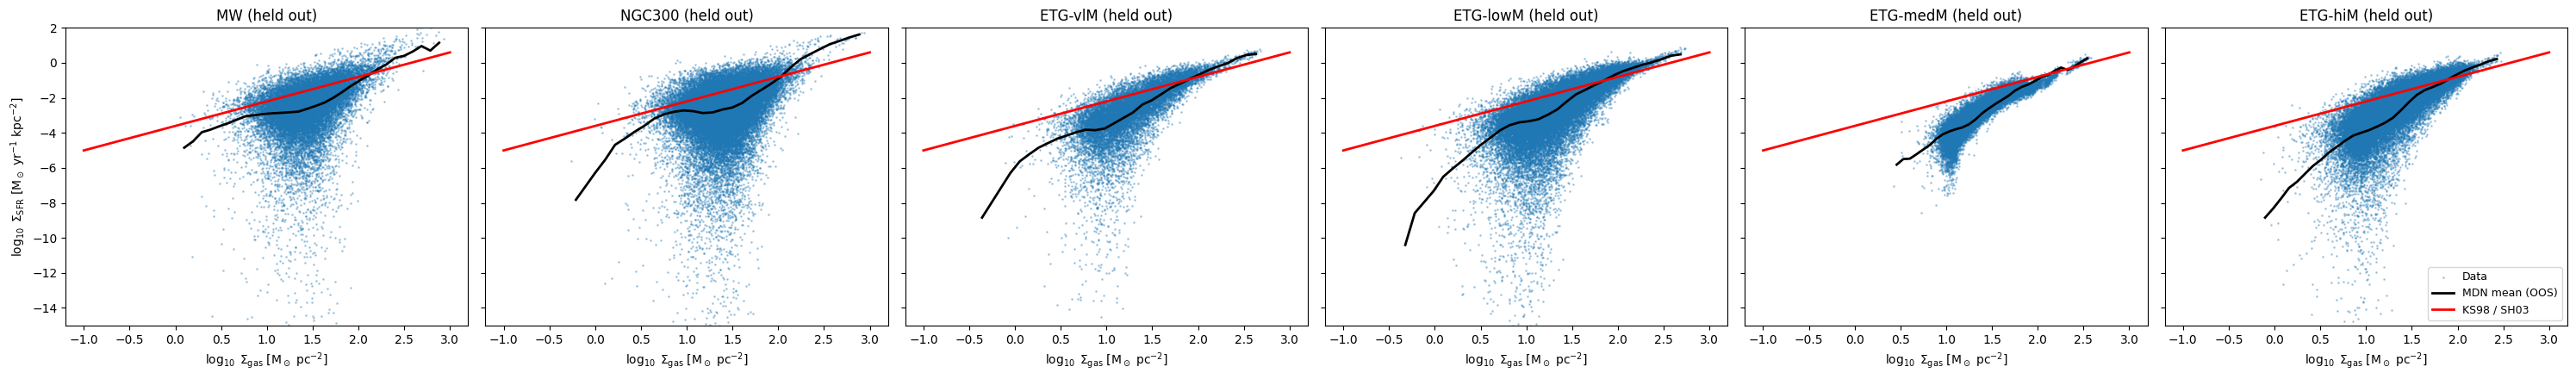

In [7]:
# KS relation with MDN mean line, per held-out galaxy
sig_gas_ks = np.logspace(-1, 3, 200)
sig_sfr_ks = 2.5e-4 * sig_gas_ks**1.4

n_gal = len(galaxy_names)
fig, axes = plt.subplots(1, n_gal, figsize=(5 * n_gal, 4.5), sharey=True)

for ax, name in zip(axes, galaxy_names):
    r = results[name]
    ctx_test, sfr_sd_test = data[name]
    log_gas = np.log10(ctx_test[:, 0] * SURFDENS_TO_MSUN_PC2)
    log_sfr_actual = np.log10(sfr_sd_test * SFR_SURFDENS_TO_MSUN_YR_KPC2)
    ax.scatter(log_gas, log_sfr_actual, s=1, alpha=0.3, label="Data")

    # MDN mean prediction
    finite_test = r["finite_test"]
    X_test_scaled = r["scaler"].transform(np.log10(ctx_test[finite_test][:, FEATURE_INDICES])).astype(np.float32)
    X_test_t = torch.tensor(X_test_scaled).to(device)
    log_sfr_pred = predict_mean(r["model"], X_test_t) + np.log10(SFR_SURFDENS_TO_MSUN_YR_KPC2)

    # Binned mean
    log_gas_v = log_gas[finite_test]
    bin_edges = np.linspace(log_gas_v.min(), log_gas_v.max(), 31)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    bin_means = np.full(30, np.nan)
    for i in range(30):
        in_bin = (log_gas_v >= bin_edges[i]) & (log_gas_v < bin_edges[i + 1])
        if in_bin.sum() > 0:
            bin_means[i] = np.mean(log_sfr_pred[in_bin])
    ok = np.isfinite(bin_means)
    ax.plot(bin_centers[ok], bin_means[ok], "k-", lw=2, label="MDN mean (OOS)")

    ax.plot(np.log10(sig_gas_ks), np.log10(sig_sfr_ks), "r-", lw=2, label="KS98 / SH03")
    ax.set_title(f"{name} (held out)")
    ax.set_xlabel(r"$\log_{10}\;\Sigma_{\rm gas}$ [M$_\odot$ pc$^{-2}$]")

axes[0].set_ylim([-15., 2.])
axes[0].set_ylabel(r"$\log_{10}\;\Sigma_{\rm SFR}$ [M$_\odot$ yr$^{-1}$ kpc$^{-2}$]")
axes[-1].legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

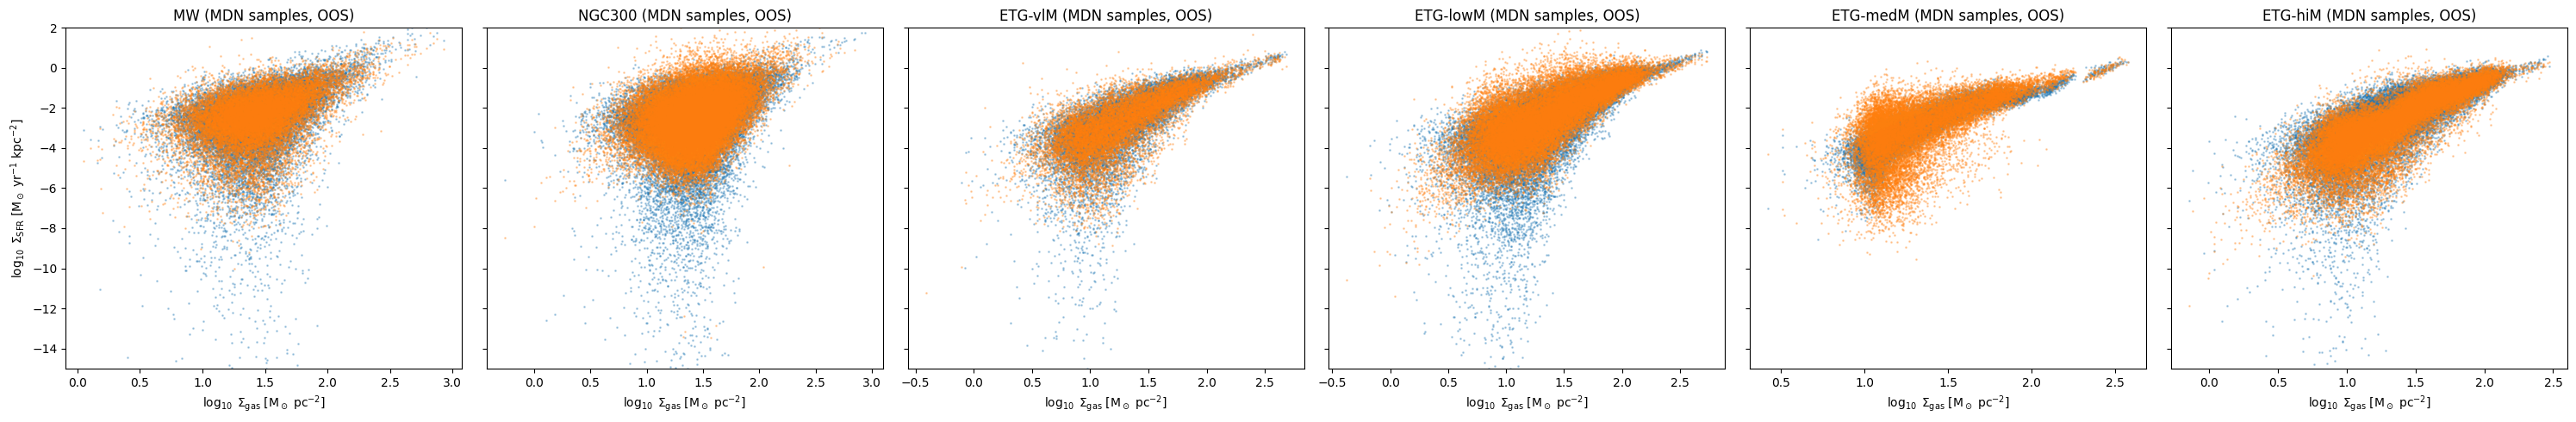

In [8]:
# Sampled KS relation per held-out galaxy
n_gal = len(galaxy_names)
fig, axes = plt.subplots(1, n_gal, figsize=(5 * n_gal, 5), sharey=True)

for col, name in enumerate(galaxy_names):
    r = results[name]
    ctx_test, sfr_sd_test = data[name]
    log_gas = np.log10(ctx_test[:, 0] * SURFDENS_TO_MSUN_PC2)

    finite_test = r["finite_test"]
    X_test_scaled = r["scaler"].transform(np.log10(ctx_test[finite_test][:, FEATURE_INDICES])).astype(np.float32)
    X_test_t = torch.tensor(X_test_scaled).to(device)
    log_sfr_sampled = sample(r["model"], X_test_t) + np.log10(SFR_SURFDENS_TO_MSUN_YR_KPC2)

    log_sfr_actual = np.log10(sfr_sd_test * SFR_SURFDENS_TO_MSUN_YR_KPC2)
    axes[col].scatter(log_gas, log_sfr_actual, s=1, alpha=0.3, label="Data")

    axes[col].scatter(log_gas[finite_test], log_sfr_sampled, s=1, alpha=0.3)
    axes[col].set_ylim([-15., 2.])
    axes[col].set_title(f"{name} (MDN samples, OOS)")
    axes[col].set_xlabel(r"$\log_{10}\;\Sigma_{\rm gas}$ [M$_\odot$ pc$^{-2}$]")

axes[0].set_ylabel(r"$\log_{10}\;\Sigma_{\rm SFR}$ [M$_\odot$ yr$^{-1}$ kpc$^{-2}$]")

plt.tight_layout()
plt.show()